# 10 Virtual Design Analysis

This notebook applies the explicit descriptor model developed in Notebook 09 to perform virtual design analysis.

The goal is to evaluate how hydrovoltaic performance responds to systematic variation of internal resistance and structural descriptors.

This analysis is intended to convert the descriptor model into a practical design map.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

print(df.shape)
df.head()

(159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,ion_type,mechanism_simple,asym_env,asym_chem,asym_electrode,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,anion,streaming,1,0,0,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,anion,streaming,1,1,0,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0


In [3]:
TARGET = "log_estimated_power_density"

candidate_features = [
    "log_internal_resistance_Mohm",
    "structure_class",
    "ion_type",
    "mechanism_simple",
    "electrolyte_present",
    "inorganic_electrolyte"
]

available_features = [c for c in candidate_features if c in df.columns]

print("Available features:")
print(available_features)

Available features:
['log_internal_resistance_Mohm', 'structure_class', 'ion_type', 'mechanism_simple']


In [4]:
# Build clean modeling table
df_model = df[available_features + [TARGET]].copy()

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=[TARGET])

print(df_model.shape)
df_model.head()

(159, 5)


,log_internal_resistance_Mohm,structure_class,ion_type,mechanism_simple,log_estimated_power_density
0,0.903090,porous,proton,streaming,-2.425853
1,1.535294,porous,anion,streaming,-2.698753
2,1.778151,porous,anion,streaming,-2.027982
3,NaN,porous,proton,streaming,-2.106738
4,NaN,porous,proton,streaming,-2.795609


In [5]:
# Identify numeric and categorical features
numeric_features = [
    c for c in available_features
    if pd.api.types.is_numeric_dtype(df_model[c])
]

categorical_features = [
    c for c in available_features
    if c not in numeric_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['log_internal_resistance_Mohm']
Categorical features: ['structure_class', 'ion_type', 'mechanism_simple']


In [6]:
# Fill missing values
for c in numeric_features:
    df_model[c] = df_model[c].fillna(df_model[c].median())

for c in categorical_features:
    df_model[c] = df_model[c].fillna("unknown").astype(str)

X = df_model[available_features]
y = df_model[TARGET]

print(X.shape, y.shape)

(159, 4) (159,)


In [7]:
# Train descriptor model
# 这里重新训练一次 09 里的 linear Elastic Net，保证 notebook 自包含。
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

descriptor_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 2, 80),
        cv=5,
        max_iter=20000,
        random_state=42
    ))
])

In [8]:
# Evaluate descriptor model
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

descriptor_model.fit(X_train, y_train)

y_train_pred = descriptor_model.predict(X_train)
y_test_pred = descriptor_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)

enet = descriptor_model.named_steps["model"]
print("Best alpha:", enet.alpha_)
print("Best l1_ratio:", enet.l1_ratio_)

Train R2: 0.33196553042937027
Test R2: 0.42857762213842443
Test RMSE: 1.0169334190138533
Test MAE: 0.8273930177607135
Best alpha: 0.009433732216299773
Best l1_ratio: 0.1


In [9]:
# Cross-validation check
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(
    descriptor_model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("CV R2 scores:", cv_r2)
print("Mean CV R2:", cv_r2.mean())
print("Std CV R2:", cv_r2.std())

c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV R2 scores: [0.30923523 0.28285927 0.29470286 0.29982824 0.06964203]
Mean CV R2: 0.2512535267699536
Std CV R2: 0.09120404225219486


In [10]:
# Define virtual design range
logR_min = df_model["log_internal_resistance_Mohm"].quantile(0.05)
logR_max = df_model["log_internal_resistance_Mohm"].quantile(0.95)
logR_median = df_model["log_internal_resistance_Mohm"].median()

logR_range = np.linspace(logR_min, logR_max, 120)

print("5% logR:", logR_min)
print("Median logR:", logR_median)
print("95% logR:", logR_max)

5% logR: -2.5100623500771886
Median logR: -0.9034377008227692
95% logR: 1.5442959531346603


In [11]:
# Inspect available categories
for c in categorical_features:
    print("\n", c)
    print(df_model[c].value_counts())


 structure_class
structure_class
porous               118
film                  22
hydrogel              14
hydrogel + porous      4
hydrogel + film        1
Name: count, dtype: int64

 ion_type
ion_type
proton          96
other_cation    54
anion            9
Name: count, dtype: int64

 mechanism_simple
mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64


In [12]:
# Define default virtual sample builder

# 注意：这里的默认值要尽量使用你数据里真实存在的类别。先跑 Cell 13 看一下，如果类别名不一样，再改。
def get_mode_value(column):
    return df_model[column].mode().iloc[0]

default_values = {}

for c in available_features:
    if c == "log_internal_resistance_Mohm":
        default_values[c] = logR_median
    elif c in numeric_features:
        default_values[c] = df_model[c].median()
    else:
        default_values[c] = get_mode_value(c)

default_values

default_values["structure_class"] = "porous"
default_values["ion_type"] = "other_cation"
default_values["mechanism_simple"] = "ion_gradient"

if "electrolyte_present" in default_values:
    default_values["electrolyte_present"] = 1

if "inorganic_electrolyte" in default_values:
    default_values["inorganic_electrolyte"] = 1

default_values

{'log_internal_resistance_Mohm': np.float64(-0.9034377008227692),
 'structure_class': 'porous',
 'ion_type': 'other_cation',
 'mechanism_simple': 'ion_gradient'}

In [13]:
# Function to build virtual dataframe
def build_virtual_df(
    logR_values,
    structure_class=None,
    ion_type=None,
    mechanism_simple=None,
    electrolyte_present=None,
    inorganic_electrolyte=None
):
    """
    Build virtual hydrovoltaic samples by sweeping log_internal_resistance_Mohm
    while fixing other descriptors.
    """
    
    rows = []
    
    for logR in logR_values:
        row = default_values.copy()
        row["log_internal_resistance_Mohm"] = logR
        
        if structure_class is not None and "structure_class" in row:
            row["structure_class"] = structure_class
            
        if ion_type is not None and "ion_type" in row:
            row["ion_type"] = ion_type
            
        if mechanism_simple is not None and "mechanism_simple" in row:
            row["mechanism_simple"] = mechanism_simple
            
        if electrolyte_present is not None and "electrolyte_present" in row:
            row["electrolyte_present"] = electrolyte_present
            
        if inorganic_electrolyte is not None and "inorganic_electrolyte" in row:
            row["inorganic_electrolyte"] = inorganic_electrolyte
        
        rows.append(row)
    
    return pd.DataFrame(rows)[available_features]

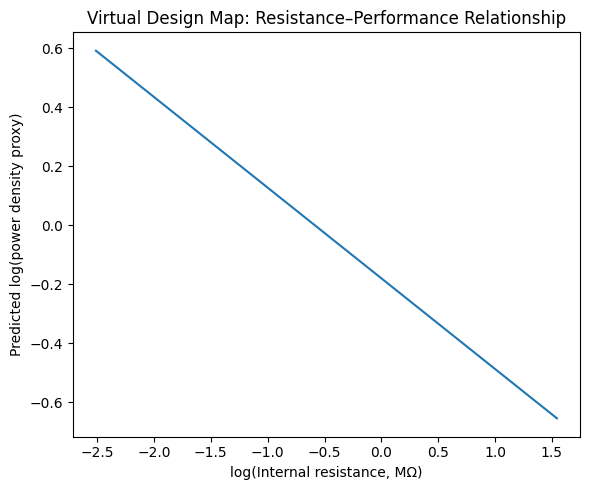

In [14]:
# Single virtual design curve
baseline_virtual = build_virtual_df(logR_range)

baseline_pred = descriptor_model.predict(baseline_virtual)

plt.figure(figsize=(6, 5))
plt.plot(logR_range, baseline_pred)

plt.xlabel("log(Internal resistance, MΩ)")
plt.ylabel("Predicted log(power density proxy)")
plt.title("Virtual Design Map: Resistance–Performance Relationship")

plt.tight_layout()
plt.show()

In [15]:
# Choose structures for comparison
structure_counts = df_model["structure_class"].value_counts()
structure_counts

structure_class
porous               118
film                  22
hydrogel              14
hydrogel + porous      4
hydrogel + film        1
Name: count, dtype: int64

In [16]:
structures_to_plot = [
    "porous",
    "film",
    "hydrogel",
    "hydrogel + film"
]

structures_to_plot = [
    s for s in structures_to_plot
    if s in df_model["structure_class"].unique()
]

print(structures_to_plot)

['porous', 'film', 'hydrogel', 'hydrogel + film']


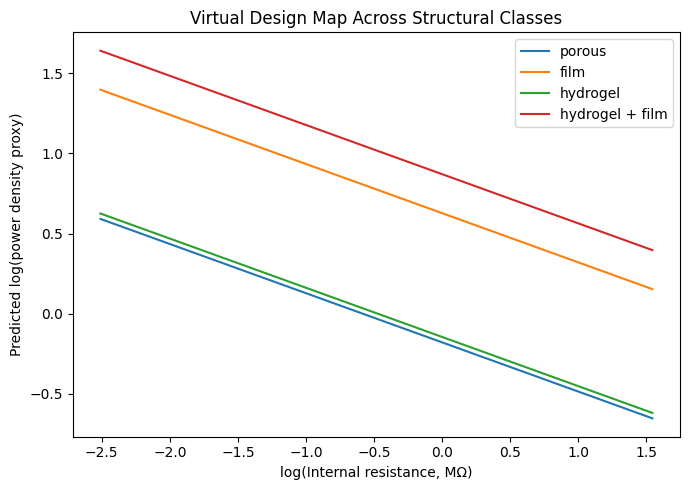

In [17]:
# Virtual design map across structures
plt.figure(figsize=(7, 5))

for s in structures_to_plot:
    df_v = build_virtual_df(
        logR_range,
        structure_class=s
    )
    y_v = descriptor_model.predict(df_v)
    plt.plot(logR_range, y_v, label=s)

plt.xlabel("log(Internal resistance, MΩ)")
plt.ylabel("Predicted log(power density proxy)")
plt.title("Virtual Design Map Across Structural Classes")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Ion type comparison
ion_counts = df_model["ion_type"].value_counts()
ion_counts

ion_type
proton          96
other_cation    54
anion            9
Name: count, dtype: int64

In [19]:
ions_to_plot = [
    "proton",
    "other_cation",
    "mixed",
    "unknown"
]

ions_to_plot = [
    ion for ion in ions_to_plot
    if ion in df_model["ion_type"].unique()
]

print(ions_to_plot)

['proton', 'other_cation']


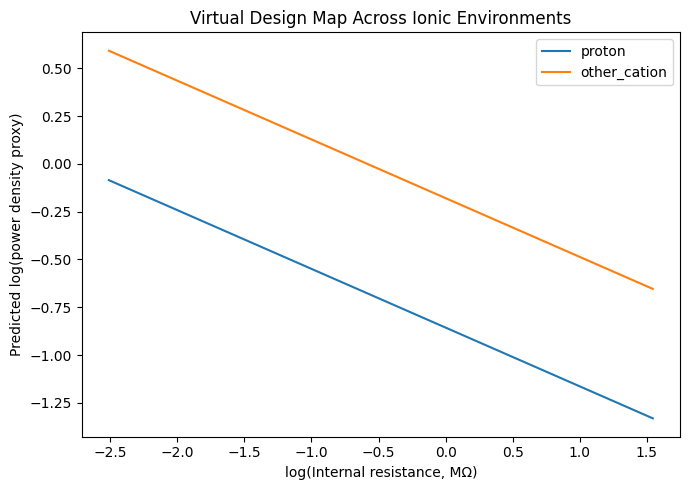

In [20]:
plt.figure(figsize=(7, 5))

for ion in ions_to_plot:
    df_v = build_virtual_df(
        logR_range,
        ion_type=ion
    )
    y_v = descriptor_model.predict(df_v)
    plt.plot(logR_range, y_v, label=ion)

plt.xlabel("log(Internal resistance, MΩ)")
plt.ylabel("Predicted log(power density proxy)")
plt.title("Virtual Design Map Across Ionic Environments")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Combined design cases table
design_cases = []

# low / median / high R for common structures
for structure in structures_to_plot:
    for label, logR in [
        ("low_R", logR_min),
        ("median_R", logR_median),
        ("high_R", logR_max)
    ]:
        design_cases.append({
            "design_case": f"{structure}_{label}",
            "structure_class": structure,
            "log_internal_resistance_Mohm": logR
        })

design_cases_df = pd.DataFrame(design_cases)
design_cases_df

,design_case,structure_class,log_internal_resistance_Mohm
0,porous_low_R,porous,-2.510062
1,porous_median_R,porous,-0.903438
2,porous_high_R,porous,1.544296
3,film_low_R,film,-2.510062
4,film_median_R,film,-0.903438
5,film_high_R,film,1.544296
6,hydrogel_low_R,hydrogel,-2.510062
7,hydrogel_median_R,hydrogel,-0.903438
8,hydrogel_high_R,hydrogel,1.544296
9,hydrogel + film_low_R,hydrogel + film,-2.510062


In [22]:
# Predict hypothetical design cases
pred_rows = []

for _, case in design_cases_df.iterrows():
    df_v = build_virtual_df(
        [case["log_internal_resistance_Mohm"]],
        structure_class=case["structure_class"]
    )
    
    pred_log_power = descriptor_model.predict(df_v)[0]
    
    pred_rows.append({
        "design_case": case["design_case"],
        "structure_class": case["structure_class"],
        "log_internal_resistance_Mohm": case["log_internal_resistance_Mohm"],
        "predicted_log_power_density_proxy": pred_log_power
    })

virtual_design_table = pd.DataFrame(pred_rows)

virtual_design_table = virtual_design_table.sort_values(
    "predicted_log_power_density_proxy",
    ascending=False
)

virtual_design_table

,design_case,structure_class,log_internal_resistance_Mohm,predicted_log_power_density_proxy
9,hydrogel + film_low_R,hydrogel + film,-2.510062,1.641727
3,film_low_R,film,-2.510062,1.398164
10,hydrogel + film_median_R,hydrogel + film,-0.903438,1.148263
4,film_median_R,film,-0.903438,0.904700
6,hydrogel_low_R,hydrogel,-2.510062,0.625319
0,porous_low_R,porous,-2.510062,0.591509
11,hydrogel + film_high_R,hydrogel + film,1.544296,0.396457
5,film_high_R,film,1.544296,0.152894
7,hydrogel_median_R,hydrogel,-0.903438,0.131855
1,porous_median_R,porous,-0.903438,0.098045


In [23]:
# Save virtual design table
virtual_design_table.to_csv(
    "../results/10_virtual_design_cases.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved virtual design cases.")

Saved virtual design cases.


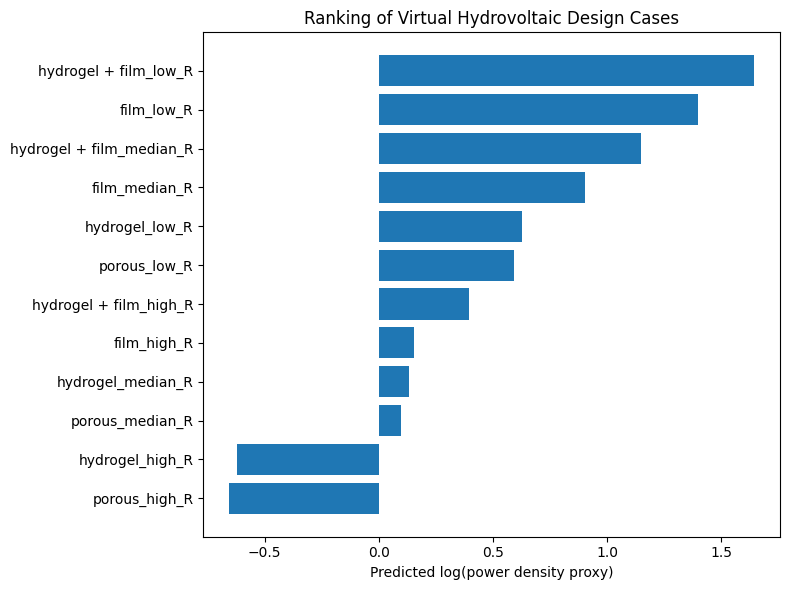

In [24]:
# Plot design case ranking
plot_df = virtual_design_table.sort_values(
    "predicted_log_power_density_proxy",
    ascending=True
)

plt.figure(figsize=(8, 6))
plt.barh(
    plot_df["design_case"],
    plot_df["predicted_log_power_density_proxy"]
)

plt.xlabel("Predicted log(power density proxy)")
plt.title("Ranking of Virtual Hydrovoltaic Design Cases")

plt.tight_layout()
plt.show()

In [25]:
# Extract design slope with respect to logR

# 这个很重要：它给你一个“设计灵敏度”。
feature_names = descriptor_model.named_steps["preprocess"].get_feature_names_out()
coefs = descriptor_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coefficient
4,cat__structure_class_porous,-0.806655,0.806655
1,cat__structure_class_hydrogel,-0.772845,0.772845
5,cat__ion_type_other_cation,0.611370,0.611370
3,cat__structure_class_hydrogel + porous,-0.367438,0.367438
0,num__log_internal_resistance_Mohm,-0.361594,0.361594
7,cat__mechanism_simple_streaming,-0.341592,0.341592
2,cat__structure_class_hydrogel + film,0.243563,0.243563
6,cat__ion_type_proton,-0.065299,0.065299


### Virtual design and performance ranking

The virtual design analysis provides a clear ranking of hydrovoltaic device configurations based on predicted performance. Across all structural classes, device performance decreases monotonically with increasing internal resistance, confirming that resistance is the dominant controlling factor.

At fixed resistance levels, structural class introduces a secondary modulation effect, with composite structures such as hydrogel + film exhibiting higher predicted performance than single-phase porous structures. However, this structural advantage is insufficient to compensate for high resistance. Notably, high-resistance configurations consistently underperform even when combined with favorable structural descriptors.

These results demonstrate that internal resistance governs the global performance landscape, while structural features shift local baselines. Consequently, reducing internal resistance is more critical than optimizing structural class for achieving high-performance hydrovoltaic devices.